In [3]:
# This is unspuervised learning algorithm which means we don't have labels 
# Agglomerative clustering is bottom up view means we work from single points up to all data sets
# We don't have classifcation or regression 
import numpy as np
# We need to draw some plots
import matplotlib.pyplot as plt
# We need to draw dendrogram and we can't make it from scratch as it is tideous and have dozend of matplotlib lines
from scipy.cluster.hierarchy import dendrogram

# For warnings
import warnings
warnings.filterwarnings('ignore')

class AgglomerativeClustering():

    # Intialization
    def __init__(self, n_clusters=2, linkage='single'):
        # Here other paramerts default as API
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.X = None
        # Intilaize linkge matrix
        # We call it linkage because calculating distance depeneds on linkage methods and it will record all history to be drawn in dendrogram
        self.linkage_matrix = None
        self.labels_ = None
        # This help us in prediction and assigning labels as prediction and assigning label is the same process as assign to the closest centroid
        self.centroids_ = None

    # Helper functions
    # Find the best merge and it is the most important function
    def _find_best_merge(self, dist_matrix, current_ids, clusters):
        # My target is to find the global min distance in all matrix
        # Intialize return value which are best distance and the best pairs
        best_dist = np.inf
        best_pair = (None, None)

        # We will loop over all current ids
        # The one current id is the iterator it self
        for i in range(len(current_ids)):
            # Each id will loop over others
            for j in range(i+1, len(current_ids)):
                # Filter the indices
                # We work with two clusters and get all related distances
                # Get all related points through cluster points dictionary
                # Don't think every time we calculate distances over and over as we have already storage for them
                c1_indices, c2_indices = clusters[current_ids[i]], clusters[current_ids[j]]
                
                # Collect all possible distances wihtin filtered indices from the primary distance matrix so that we not calculate the euclidean distances again
                sub_dist = dist_matrix[np.ix_(c1_indices, c2_indices)]
                
                # Based on the linkage method the final distance will be one of these
                if self.linkage == 'single': 
                    d = np.min(sub_dist)
                elif self.linkage == 'complete':
                    d = np.max(sub_dist)
                elif self.linkage == 'average': 
                    # For average method
                    d = np.mean(sub_dist) 
                elif self.linkage == 'ward':
                    # For ward's method
                    # Formula => ΔSSE = (n1*n2)/(n1+n2) * ||mu1 - mu2||^2
                    # N means the number of indices and mu is the mean of the indices which is sum(indices) / num(indice)
                    n1 = len(c1_indices)
                    n2 = len(c2_indices)
                    # X[c_indices] is 2D matrix (m, n) so mean will produce 1D matrix which (nmeans, )
                    mu1 = np.mean(self.X[c1_indices], axis = 0)
                    mu2 = np.mean(self.X[c2_indices], axis = 0)
                    d = (n1+n2) / (n1*n2) * np.sum((mu1*mu2) ** 2)
                else:
                    # Handle error of methods
                    raise ValueError('Method not found.')
                    
                if d < best_dist:
                    # The least distance with its pairs should return
                    best_dist = d
                    # The best pair will be current ids for i and j
                    best_pair = (current_ids[i], current_ids[j])

        return best_pair[0], best_pair[1], best_dist
    
    # Silhouette function
    def _calculate_silhouette(self, X):
    # Get samples number
        n_samples = X.shape[0]

        # Get all scores cause later we get the mean
        silhouette_vals = []
        
        # loop over all points and inside each iteration we have another loop for the closest cluster
        for i in range(n_samples):
            # Get a(i) so we work in the same cluster
            # Get the cluster of point first
            inside_cluster = X[self.labels_ == self.labels_[i]]
            if len(inside_cluster) > 1:
                # Make sure it is has more than two points
                # Inside cluster is the current cluster points
                a = np.mean(np.linalg.norm(inside_cluster - X[i], axis=1))
            else:
                # No points so no averga
                a = 0

            # intialize b to get min b at the end 
            b = np.inf
            # Loop over other cluster
            for label in range(self.n_clusters):
                # Get b(i) so we work with the closets cluster ignoring our current one
                if label == self.labels_[i]:
                    continue
                
                # Each time we calcualte b till we get the min one
                # Outside cluster is the outer current cluster points
                outside_cluster = X[self.labels_ == label]
                
                if len(outside_cluster)>0:
                    # Make sure it has point
                    current_b = np.mean(np.linalg.norm(outside_cluster - X[i], axis=1))
                    b = min(b, current_b)

            # Calcualte silhouette for current point and to be added later to the silhouette_vals
            # Add stability term to avoid zero devsion
            s = (b - a)  / (max(a, b) + 1e-9)       
            silhouette_vals.append(s)

        # Get the average of all score
        return np.mean(silhouette_vals)    
    
    # Fit
    def fit_predict(self, X):
        # Convert x to array
        X = np.array(X) 
        self.X = X
        # get samples number
        n_samples = X.shape[0]

        # i = 0
        # Step 0 --> Consider every point as sperated cluster at i = 0 
        # Here the arch is cluster : its points
        # Dictionary to store all points 
        # i are the cluster and the point at the same time so cluster as key : point as value
        clusters = {i : [i] for i in range(n_samples)}

        # Step 1 --> calculate distances between all points (clusters)
        # First time it gonna be euclidean distanceso it is only distance matrix 
        # Next will be simialarity (proximity) (linkage)
        # we use np.newaxis as X is (m X n) and X (m X n) so we can't devide all i need to devide each sample point from all others at once to avoid getting zero
        # So convert from (m x n) to (m x 1 x n) 3D matrix (samples, new axis to devide and n) to get (m, m, n_differ) so it is 3D
        # The new matrix is ndiffe x ndiffer
        # Axis = 2 refers to old matrix and stored in new
        dist_matrix = np.sqrt(np.sum((self.X[:, np.newaxis] - self.X)**2, axis=2))
        # Fill diagnol with infinity as the distance between point and itself is zero but we make as inf for safety
        # Zero could be least so we will merge point with itself and that is a waste of time
        np.fill_diagonal(dist_matrix, np.inf)

        # Record all linkage distcance to view in dendrogram
        self.linkage_matrix = []

        # Start of journey
        # We start with full cacapit of all curren_ids and 0 capcaity for next_cluster_ids
        # Detect current clusters and next cluster as we get one per iteration
        # Will be decreased with time as every time ids get less and less for merge
        current_clusters_ids = list(clusters.keys())
        # Normal the next cluster at next iterations 
        # Will be increased with time as every time new key added with new merged cluster
        next_cluster_ids= n_samples

        while len(current_clusters_ids) > 1 :
            # You build the whole tree 
            # I should have more than one cluster
            # The iteration is not specified with range it is specified till we got one cluster so stop case is one cluster and another rules
            # Step 2 --> find the best merge
            # I got the best merge (global min distance) through passing distance matrix, current clusters and the clusters
            # We will use linkage method
            # May target is get the best pair
            # Every time the dist_matrix is the same and the update of clusters which is the dictionary of the current clusters and current_clusters_ids 
            # Here we filter the current_cluster_ids with the pairs which have the min global distance
            c1, c2, min_dist = self._find_best_merge(dist_matrix, current_clusters_ids, clusters)

            # Record distnace to view it in dendrogram
            # Filter by clusters to get the current points if the pairs
            new_size = len(clusters[c1] + clusters[c2])
            # Record history for every iteration in linkage matrix
            # We pass all ids of c1 and c2 their distance and their count
            # We make explict casting as float because SciPy dendrogram is comfortable with float arrays
            self.linkage_matrix.append([float(c1), float(c2), float(min_dist), new_size])

            # Merge and get one new cluster
            # Merge the best ids together to get one cluster
            new_clusters = clusters[c1] + clusters[c2]
            # Update the clusters (points) dictionary to make the merged points refer to the new cluster rather than the old one
            # So new key is added and all old keys were preserved from 0 to nsamples - 1 as the first new will be nsamples which will assigned by next_clusters_ids
            # We don't remove anything from clusters dictionary we just add
            clusters[next_cluster_ids] = new_clusters

            # Update current ids
            # Remove first the previous two clusters as they are one new cluster now
            current_clusters_ids.remove(c1)
            current_clusters_ids.remove(c2)
            # Add the new merged cluster to the current
            # Instead of old keys now they are just new keys 
            current_clusters_ids.append(next_cluster_ids)

            # Check if we reach the desired n_clusters
            # Current_clusters_ids get less and lesser
            # Stopping criteria and it is like storage at this condition only but you buid the whole tree
            # Assigning labels adding centroids to cluster and this part is the same process like prediction
            if len(current_clusters_ids) == self.n_clusters:
                # Intialize labels
                self.labels_ = np.zeros(n_samples)
                # Intialize centroids
                # Num of centroids ==> num of clusters x num of features with comfortable float data type
                self.centroids_ = np.zeros((self.n_clusters, self.X.shape[1]), dtype=float)

                for cluster_label, c_id in enumerate(current_clusters_ids):
                    # Cluster _label --> 0, 1, 2 and c_id is the id of cluster in the current and each id related to cluster in dictionary
                    # Assign labels to each cluster (0, 1, 2 etc)
                    # Dictionaty point : label
                    # Fetch points through search in clusters dictionary with the id of clusters and make a key in labels 
                    # So key is real cluster id : label
                    self.labels_[clusters[c_id]] = cluster_label
                    # Add centroids for later prediction
                    # Cenroids added per cluster_label
                    # Centroids is just key and value where cluster_label(already dictionary) : mean of points if this cluster label
                    self.centroids_[cluster_label] = np.mean(self.X[clusters[c_id]]) 

                    
            # Go to next level
            next_cluster_ids += 1

        # Convert the final linkage_matrix to numpy array
        self.linkage_matrix = np.array(self.linkage_matrix)
        
        # Silhouette case always
        self.silhouette_ = self._calculate_silhouette(X)
        return self

    # Predict
    def predict(self, X_test):
        # Here it is just geaometric prediction
        # Convert X to array
        # Comfortable with float data type
        X_test = np.array(X_test, dtype=float)
        # Return predicstions
        preds = []
        for x in X_test:
            # Here we assign cluster based on the standard method which is geometric assignment (centroids based)
            # Get all distances with points 
            # Index represents sample and column represents differ
            # Cetroids are (m, n) and x is (,n) result will be (mdiffer, n)
            # Get norm from axis = 1 which norm of each feature difference
            # dist is 1D matrix (mdist,)
            dists = np.linalg.norm(self.centroids_ - x, axis=1)
            # Assign label of nearest distance and assign its labal
            preds.append(self.labels_[np.argmin(dists)])
        return np.array(preds)
    
    # Dendrogram draw
    def plot_dendrogram(self):
        # Plotly size
        plt.figure(figsize=(10, 5))
        # Pass linkage matrix to dendrogram like sch.linkage
        # It contains all history
        dendrogram(self.linkage_matrix)
        plt.title(f"Agglomerative Dendrogram ({self.linkage})")
        plt.show()

Calculating Elbow Method...


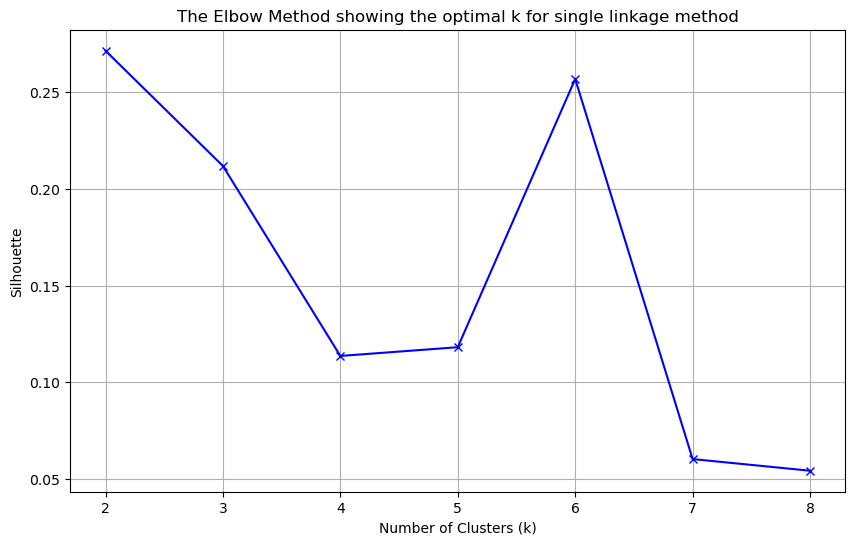

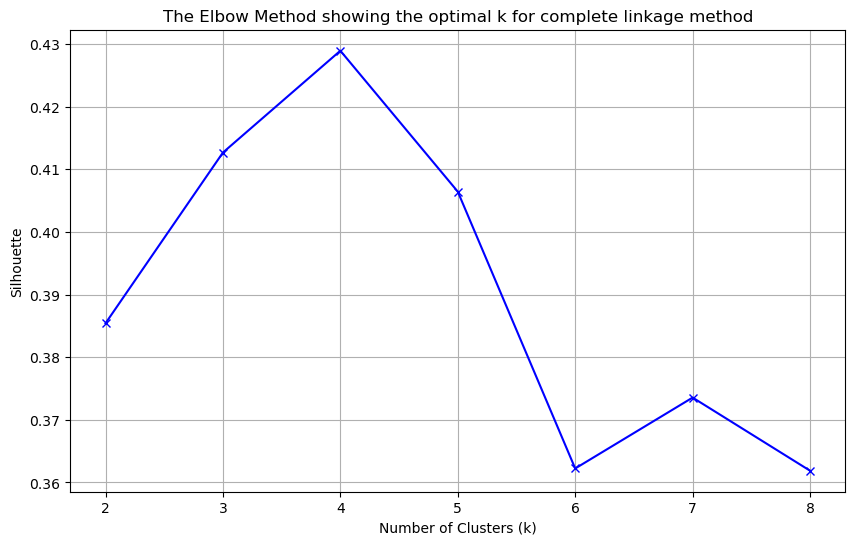

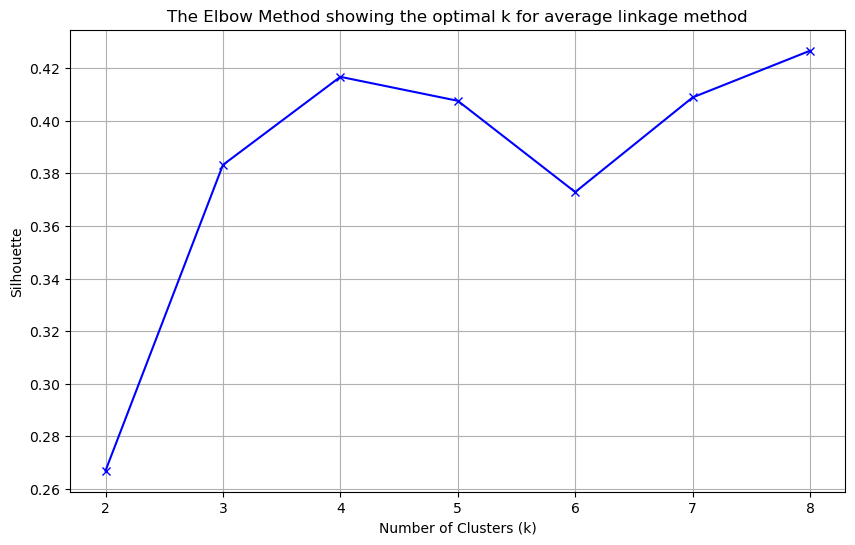

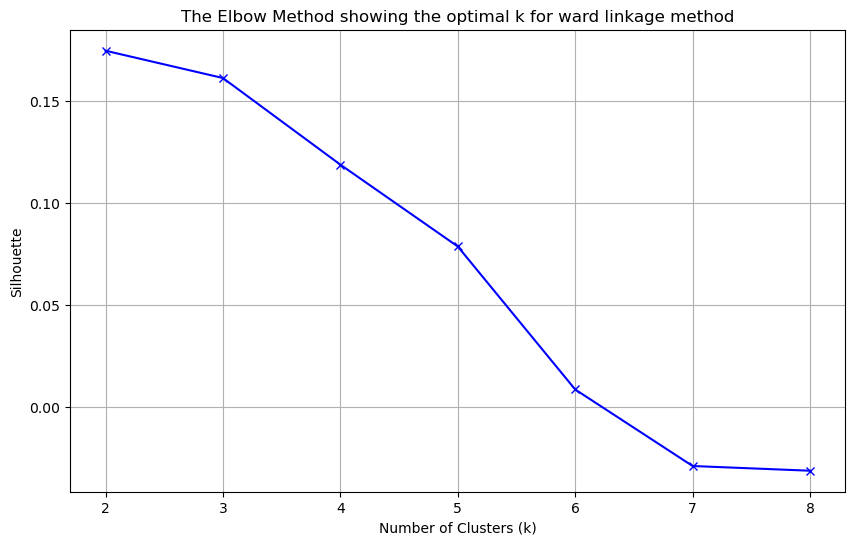

In [4]:
# For plotting purposes
import matplotlib.pyplot as plt

# Sample data
# Create number of rows and random x and y matrices
m = 100
# Use rand then multiple by 2 to make sure the samples values are between 0 and 2 this would make sure we simulate feature scaling
# Here we create 2 features
X1 = 2 * np.random.rand(m, 1)
X2 = 2 * np.random.rand(m, 1)
# Combine features to create X matrix
# We work only with x as y (label not exist)
X = np.column_stack((X1, X2))

# Test data with 2 rows
X_new = np.array([[1,2], [3,4], [4,3]])

# Get the best K using Elblow method
print("Calculating Elbow Method...")

K = 9
# Apply default agglomerative with all possible parameters 
linkage_methods = ['single', 'complete', 'average', 'ward']
for linkage_method in linkage_methods:
    # Collect all silhouette scores vs K
    silhouette_scores = []
    for cluster_no in range(1, K):
        model = AgglomerativeClustering(n_clusters=cluster_no, linkage=linkage_method)
        model.fit_predict(X)
        silhouette_scores.append(model.silhouette_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, K), silhouette_scores, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette')
    plt.title(f'The Elbow Method showing the optimal k for {linkage_method} linkage method')
    plt.grid(True)
    plt.show()

In [11]:
# k = 4 and complete method are the best silheutte score 
k = 4
linkage_method = 'complete'

print(f'Model: Agglomarative')
# Get Agglomerative Clustering default object
agg_model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
agg_model.fit_predict(X)
pred = agg_model.predict(X_new)
print(f'Linkage method: {linkage_method}')
print(f'Predictions for {X_new.tolist()}: {pred}')
print(f'Evaluation score: {agg_model.silhouette_:.2f}')

Model: Agglomarative
Linkage method: complete
Predictions for [[1, 2], [3, 4], [4, 3]]: [2. 2. 2.]
Evaluation score: 0.43


Dendrogram:


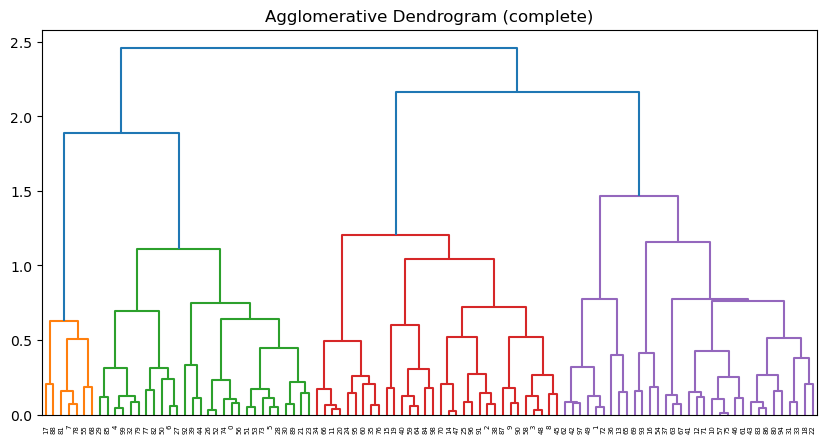

In [12]:
print('Dendrogram:')
agg_model.plot_dendrogram()